In [ ]:
# This installs all the tools we need.
!pip install openai-whisper
!pip install gtts
!pip install pydub
!pip install jiwer
!pip install audiomentations
!pip install librosa soundfile
!pip install transformers datasets accelerate
!pip install torch torchaudio

print("All packages installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=ca9b5ec8fd8f790343a7397555d70e319e86f12abccb9c8a20d41fa7b61fa257
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.4.0
    Uninstalling click-8.4.0:
      Successfully uninstalled click-8.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.27.0 requires click>=8.2.0, but you have click 8.1.8 which is in

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Creation of project folder
PROJECT_DIR = '/content/drive/MyDrive/MedASR_Project'
AUDIO_DIR = f'{PROJECT_DIR}/audio'
NOISY_DIR = f'{PROJECT_DIR}/audio_noisy'
RESULTS_DIR = f'{PROJECT_DIR}/results'

for folder in [PROJECT_DIR, AUDIO_DIR, NOISY_DIR, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Folders created at:", PROJECT_DIR)

Mounted at /content/drive
Folders created at: /content/drive/MyDrive/MedASR_Project


In [ ]:
# These are the sentences we will convert to audio.
# They are written the way a real doctor in India speaks, mixing Hindi and English naturally.
sentences = [
    "पेशेंट को तीन दिन से बुखार है और सर दर्द भी हो रहा है",
    "मुझे सुबह उठते ही चेस्ट पेन होती है",
    "उसकी बीपी रीडिंग 140 ओवर 90 है जो हाई है",
    "पेशेंट को ब्रीदलेसनेस हो रही है एस्पेशली रात को",
    "हाथ पैर में बहुत स्वेलिंग है पिछले दो दिन से",
    "पेट में दर्द है और लूज़ मोशन भी चल रहे हैं",
    "उसकी शुगर फास्टिंग में 180 आई है जो कंसर्निंग है",
    "पेशेंट को कफ है और बलगम भी आ रहा है",
    "बैक पेन बहुत सीवियर है और लेग तक जा रहा है",
    "आँखों में इरिटेशन और रेडनेस है कल से",
    "पैरासिटामोल 500mg सुबह शाम खाना खाने के बाद लेनी है",
    "मेटफॉर्मिन 500mg एक टैबलेट दिन में दो बार लेनी है",
    "ओमेप्राज़ोल खाने से 30 मिनट पहले लेना ज़रूरी है",
    "अम्लोडिपिन 5mg रोज़ रात को सोने से पहले लेनी है",
    "एज़िथ्रोमाइसिन 500mg 5 दिन तक कम्पलीट करनी है",
    "इबुप्रोफेन 400mg पेन के वक्त लेते हैं खाना खाने के साथ",
    "एटोरवास्टेटिन 10mg रात को सोने से पहले लेनी है",
    "अमोक्सिसिलिन 500mg तीन बार दिन में लेनी है",
    "पैंटोप्राज़ोल सुबह खाली पेट लेनी है",
    "सेटिरिज़िन 10mg एक टैबलेट रात को लेनी है एलर्जी के लिए",
    "इस पेशेंट को टाइप 2 डायबिटीज़ है और उन्हें डाइट कंट्रोल करना होगा",
    "हाइपरटेंशन का डायग्नोसिस कन्फर्म हुआ है और लाइफस्टाइल चेंजेस ज़रूरी हैं",
    "ईसीजी में साइनस टैकीकार्डिया दिख रही है",
    "चेस्ट एक्सरे नॉर्मल है कोई कंसोलिडेशन नहीं है",
    "एचबीए1सी 8.5 परसेंट आया है जो पूअर ग्लाइसेमिक कंट्रोल दिखाता है",
    "कम्पलीट ब्लड काउंट में हीमोग्लोबिन लो है एनीमिया है",
    "यूरिन कल्चर में ई कोलाई ग्रोथ आई है यूटीआई कन्फर्म है",
    "थायरॉइड टीएसएच लेवल हाई है हाइपोथायरॉइडिज़्म का केस है",
    "डेंगू एनएस1 एंटीजन पॉज़िटिव आया है एडमिट करना पड़ेगा",
    "किडनी फंक्शन टेस्ट में क्रिएटिनिन थोड़ा एलिवेटेड है",
    "पानी बहुत ज़्यादा पीना है दिन में कम से कम 3 लीटर",
    "नमक और तेल बिल्कुल कम करना है बीपी कंट्रोल के लिए",
    "खाने में ग्रीन वेजिटेबल्स ज़्यादा लेनी हैं शुगर के लिए",
    "रोज़ सुबह 30 मिनट वॉक करना ज़रूरी है",
    "फॉलो अप 2 हफ्ते में आना है ब्लड टेस्ट के साथ",
    "स्मोकिंग बिल्कुल बंद करनी है लंग्स के लिए",
    "वेट कंट्रोल करना बहुत ज़रूरी है",
    "स्ट्रेस मैनेज करना सीखना होगा",
    "नींद पूरी लेनी है कम से कम 7 से 8 घंटे",
    "अल्कोहल बिल्कुल नहीं लेनी है लिवर के लिए",
    "पेशेंट अनकॉन्शस हो गए हैं तुरंत एडमिट करना पड़ेगा",
    "ब्लड प्रेशर बहुत लो है 80 ओवर 50 इमरजेंसी है",
    "ऑक्सीजन सैचुरेशन 88 परसेंट है ऑक्सीजन लगानी पड़ेगी",
    "हार्ट रेट 140 है टैकीकार्डिया है आईवी लाइन लगाओ",
    "पेशेंट को सीवियर एलर्जिक रिएक्शन हो रहा है एड्रेनालिन दो",
    "ग्लूकोज़ 40 है हाइपोग्लाइसेमिया है तुरंत डेक्सट्रोज़ चढ़ाओ",
    "ब्लड लॉस हो रहा है ट्रांसफ्यूज़न की ज़रूरत है",
    "सीज़र आ रही है डायज़ेपाम आईवी देना होगा",
    "पिछली बार दिया था मेटफॉर्मिन तो कुछ फर्क पड़ा क्या",
    "शुगर कितनी आ रही है घर पर चेक करते हो",
    "दवाई रेगुलर ले रहे हो या मिस होती है कभी कभी",
    "कोई साइड इफेक्ट तो नहीं है दवाई से",
    "कोलेस्ट्रॉल कंट्रोल हो रहा है डाइट से",
    "बीपी की मशीन घर पर है क्या डेली चेक करो",
    "आज टेस्ट रिपोर्ट ले आए क्या देखते हैं क्या रिज़ल्ट है",
    "वेट में कोई चेंज आया है इस हफ्ते",
    "बच्चे को फीवर 102 डिग्री है और वॉमिटिंग भी हो रही है",
    "वैक्सीनेशन कार्ड लाना था नेक्स्ट विज़िट पे",
    "वेट फॉर एज चार्ट में थोड़ा बिलो एवरेज है",
    "बच्चे का हीमोग्लोबिन लो है आयरन सप्लीमेंट देना होगा",
    "स्कूल में ध्यान नहीं लगता थोड़ा चेक करवाना होगा",
    "दूध पिलाना बंद करो सॉलिड फूड स्टार्ट करो",
    "एंजियोप्लास्टी के बाद एस्पिरिन लाइफलॉन्ग लेनी पड़ेगी",
    "स्टेंट लगा है तो प्लाविक्स भी लेनी है 1 साल तक",
    "इको में इजेक्शन फ्रैक्शन 45 परसेंट है",
    "स्ट्रेस टेस्ट नॉर्मल आया है कोई ब्लॉकेज नहीं दिख रहा",
    "ट्रोपोनिन लेवल्स एलिवेटेड हैं मायोकार्डियल इन्फार्क्शन रूल आउट करना होगा",
    "पेशेंट को स्ट्रोक के सिम्टम्स हैं फेस ड्रूपिंग और आर्म वीकनेस",
    "एमआरआई ब्रेन में कोई एक्यूट इन्फार्क्ट नहीं दिख रहा",
    "माइग्रेन के लिए सुमाट्रिप्टान दिया है अटैक के वक्त लेना है",
    "सीज़र हिस्ट्री है तो ड्राइविंग नहीं करना 1 साल तक",
    "मेमोरी लॉस की कम्प्लेंट है डिमेंशिया स्क्रीन करना होगा",
    "आज कैसा फील कर रहे हो पहले से बेटर है क्या",
    "खाना पूरा खा रहे हो या एपेटाइट कम है",
    "रात को नींद आ रही है या डिस्टर्ब रहती है",
    "कोई टेंशन स्ट्रेस तो नहीं है घर में या ऑफिस में",
    "फैमिली में किसी को डायबिटीज़ या बीपी तो नहीं है",
    "पहले कोई ऑपरेशन हुआ है या हॉस्पिटल में एडमिट थे कभी",
    "कोई एलर्जी है दवाई से या खाने से",
    "इन्श्योरेंस है तो रेफरल दे देता हूँ स्पेशलिस्ट के लिए",
    "फास्टिंग ब्लड शुगर 126 से ज़्यादा है डायबिटीज़ कन्फर्म है",
    "एलएफटी रिपोर्ट नॉर्मल है लिवर ठीक है",
    "विटामिन डी डेफिशियेंसी है सप्लीमेंट लेना पड़ेगा",
    "यूरिक एसिड हाई है गाउट का रिस्क है",
    "लिपिड प्रोफाइल में एलडीएल 160 है मेडिकेशन स्टार्ट करनी पड़ेगी",
    "प्लेटलेट काउंट लो है प्लीज़ रेस्ट करो",
    "ईएसआर और सीआरपी एलिवेटेड हैं इन्फेक्शन है बॉडी में",
    "एचआईवी टेस्ट नेगेटिव आया है",
    "मलेरिया रैपिड टेस्ट नेगेटिव है",
    "कोविड रैपिड एंटीजन टेस्ट का रिज़ल्ट नेगेटिव है",
    "अपेंडिक्स में इन्फेक्शन है ऑपरेशन करना पड़ेगा",
    "किडनी स्टोन 8mm का है लिथोट्रिप्सी कंसीडर करेंगे",
    "हर्निया है ऑपरेशन के बाद हेवी वेट मत उठाना",
    "कैटरेक्ट सर्जरी सिम्पल है 20 मिनट की प्रोसीजर है",
    "टॉन्सिल्स बार बार इन्फेक्ट हो रहे हैं सर्जरी सोचनी पड़ेगी",
    "यह लिख लो सब दवाइयाँ एक कागज़ पर",
    "फार्मेसी से जेनेरिक ब्रांड लोगे तो सस्ता पड़ेगा",
    "3 दिन में बेटर नहीं हुए तो वापस आओ",
    "नेक्स्ट अपॉइंटमेंट 2 वीक बाद है बुकिंग करा लेना",
    "टेस्ट रिपोर्ट्स व्हाट्सएप पर भेज देना रिव्यू कर लूँगा",
    "गैस्ट्राइटिस है खाली पेट मत रहना कुछ खाके दवाई लो",
    "कॉन्स्टिपेशन के लिए इसबगोल रात को पानी में लेना है",
    "स्किन रैश के लिए कैलामाइन लोशन यूज़ करो",
    "ईयर में पेन है ईयर ड्रॉप्स दिए हैं 5 दिन तक लेना है",
    "जॉइंट पेन के लिए फिज़ियोथेरेपी रेकमेंड करूँगा",

# === CARDIOLOGY (30 sentences) ===
"एंजाइना के दर्द में नाइट्रोग्लिसरीन जीभ के नीचे रखनी है",
"कार्डिएक एंजाइम्स एलिवेटेड हैं एडमिशन ज़रूरी है",
"पेसमेकर इम्प्लांटेशन के बाद MRI नहीं होगा",
"ब्लड प्रेशर दोनों आर्म्स में चेक करो",
"होल्टर मॉनिटर 24 घंटे लगाना है",
"वैरिकोज़ वेन्स के लिए कम्प्रेशन स्टॉकिंग पहनो",
"डीप वेन थ्रॉम्बोसिस का रिस्क है बेड रेस्ट नहीं करना",
"कार्डिएक रिहैबिलिटेशन प्रोग्राम जॉइन करना होगा",
"एट्रियल फिब्रिलेशन है एंटीकोएगुलेंट शुरू करते हैं",
"वार्फेरिन पर हो तो INR रेगुलर चेक करो",
"एकोकार्डियोग्राफी में माइट्रल वाल्व लीकेज है",
"डोबुटामाइन स्ट्रेस टेस्ट करवाना है",
"कोरोनरी आर्टरी डिज़ीज़ है एंजियोग्राफी ज़रूरी है",
"हार्ट फेलियर है सोडियम और फ्लूइड रिस्ट्रिक्शन चाहिए",
"फ्यूरोसेमाइड 40mg सुबह लेनी है एडिमा के लिए",
"कार्वेडिलोल धीरे धीरे शुरू करते हैं हार्ट फेलियर में",
"लिपिड प्रोफाइल हर 6 महीने में चेक करवाओ",
"ओमेगा 3 फैटी एसिड सप्लीमेंट लेना शुरू करो",
"स्टेटिन के साथ CoQ10 सप्लीमेंट ले सकते हो",
"पल्स रेट 48 है ब्रैडीकार्डिया है कार्डियोलॉजिस्ट को दिखाओ",
"चेस्ट टाइटनेस और डायफोरेसिस है इमरजेंसी है",
"कार्डियक कैथेटेराइज़ेशन के बाद 4 घंटे फ्लैट लेटना है",
"एस्पिरिन 75mg और क्लोपिडोग्रेल दोनों लेनी हैं",
"बीटा ब्लॉकर अचानक बंद मत करो",
"पोटेशियम लेवल 3.2 है हाइपोकेलेमिया है सप्लीमेंट दो",
"पेरीकार्डाइटिस है आईबुप्रोफेन और रेस्ट की ज़रूरत है",
"हाइपरट्रॉफिक कार्डियोमायोपैथी है स्ट्रेनुअस एक्सरसाइज़ बंद करो",
"कार्डिएक मार्कर्स हर 6 घंटे में लो",
"12 लीड ECG तुरंत करो",
"इकोकार्डियोग्राम रिपोर्ट में EF 35 परसेंट है",

# === ENDOCRINOLOGY (30 sentences) ===
"इंसुलिन ग्लार्जिन रात को बेड टाइम पर लेनी है",
"HbA1c टारगेट 7 परसेंट से कम रखना है",
"हाइपोग्लाइसेमिया हो तो तुरंत ग्लूकोज़ की गोली खाओ",
"CGM लगाने से शुगर कंट्रोल बेहतर होगा",
"मेटफॉर्मिन से लैक्टिक एसिडोसिस का रिस्क है किडनी चेक रखो",
"SGLT2 इनहिबिटर शुरू करते हैं वज़न भी घटेगा",
"GLP-1 एगोनिस्ट इंजेक्शन हफ्ते में एक बार है",
"थायरॉइड में सूजन है USG नेक करवाओ",
"लेवोथायरॉक्सिन खाली पेट लेनी है बाकी दवाइयों से 4 घंटे अलग",
"थायरॉइड कैंसर का संदेह है बायोप्सी करेंगे",
"हाइपरथायरॉइडिज़्म है मेथिमाज़ोल शुरू करते हैं",
"रेडियोआयोडीन थेरेपी के बाद आइसोलेशन में रहना होगा",
"ऑस्टियोपोरोसिस है DEXA स्कैन करवाओ",
"कैल्शियम और विटामिन D रोज़ लेना है",
"एड्रेनल इनसफिशिएंसी है हाइड्रोकोर्टिसोन ज़रूरी है",
"PCOS है ओरल कॉन्ट्रासेप्टिव पिल्स और मेटफॉर्मिन दे रहा हूँ",
"प्रोलैक्टिन हाई है पिट्यूटरी MRI करवाओ",
"डायबेटिक रेटिनोपैथी स्क्रीनिंग साल में एक बार ज़रूरी है",
"डायबेटिक फुट केयर बहुत ज़रूरी है नंगे पाँव मत चलो",
"माइक्रोएल्बुमिन्यूरिया पॉज़िटिव है नेफ्रोपैथी शुरू हो रही है",
"ग्लूकागन किट घर पर रखो इमरजेंसी के लिए",
"इंसुलिन साइट रोटेट करो लिपोहाइपरट्रॉफी होगी वरना",
"फास्टिंग C-पेप्टाइड चेक करो टाइप 1 और 2 डिफरेंशिएट करने के लिए",
"डायबेटिक नेफ्रोपैथी है प्रोटीन इंटेक कम करो",
"एक्रोमेगाली का संदेह है IGF-1 लेवल चेक करो",
"कुशिंग सिंड्रोम के लिए 24 घंटे यूरिन कोर्टिसोल चाहिए",
"मल्टीपल एंडोक्राइन नियोप्लेज़िया का फैमिली हिस्ट्री है",
"डायबेटिक न्यूरोपैथी है गाबापेंटिन शुरू करते हैं",
"थायरॉइड स्टॉर्म का रिस्क है ICU में रखो",
"प्री-डायबीटीज़ है अभी से लाइफस्टाइल मोडिफिकेशन करो",

# === RESPIRATORY (25 sentences) ===
"अस्थमा का अटैक है सालबुटामोल नेब्युलाइज़ेशन दो",
"COPD है पल्मोनरी फंक्शन टेस्ट करवाओ",
"स्पाइरोमेट्री में FEV1/FVC रेशो कम है ऑब्स्ट्रक्शन है",
"इनहेलर टेक्नीक सही नहीं है मैं दिखाता हूँ",
"लॉन्ग एक्टिंग ब्रोन्कोडाइलेटर सुबह शाम इस्तेमाल करो",
"निमोनिया है एंटीबायोटिक्स 7 दिन लेनी हैं",
"CT चेस्ट में पल्मोनरी एम्बोलिज़्म का संदेह है",
"D-डाइमर एलिवेटेड है हेपेरिन शुरू करते हैं",
"ट्यूबरकुलोसिस है DOTS प्रोग्राम से ट्रीटमेंट होगा",
"सार्कोइडोसिस का संदेह है हाई रेसोलूशन CT करवाओ",
"स्लीप एपनिया है पॉलीसोम्नोग्राफी करवाओ",
"CPAP मशीन से स्लीप एपनिया कंट्रोल होगा",
"ऑक्सीजन सैचुरेशन घर पर चेक करो पल्स ऑक्सीमीटर से",
"इंटरस्टिशियल लंग डिज़ीज़ है पल्मोनोलॉजिस्ट के पास भेज रहा हूँ",
"प्लूरल इफ्यूज़न है थोरेकोसेंटेसिस करनी पड़ेगी",
"ब्रोन्कोस्कोपी से बायोप्सी लेंगे",
"एलर्जिक राइनाइटिस है स्टेरॉइड नेज़ल स्प्रे यूज़ करो",
"एलर्जेन अवॉइडेंस सबसे ज़रूरी है",
"घर में धूल और पालतू जानवरों से दूर रहो",
"फ्लू वैक्सीन हर साल लगवाओ",
"न्यूमोकोकल वैक्सीन 65 साल के बाद ज़रूरी है",
"हेमोप्टेसिस है तुरंत CT चेस्ट करवाओ",
"लंग कैंसर स्क्रीनिंग के लिए low-dose CT है",
"एम्फीसेमा में pursed lip breathing सिखाओ",
"रेस्पिरेटरी फिज़ियोथेरेपी रोज़ करनी है",

# === GASTROENTEROLOGY (25 sentences) ===
"इरिटेबल बाउल सिंड्रोम है स्ट्रेस मैनेजमेंट और डाइट ज़रूरी है",
"GERD के लिए खाने के बाद 2-3 घंटे सीधे बैठो",
"रात को खाना सोने से 3 घंटे पहले खाओ",
"एंडोस्कोपी में H. pylori इन्फेक्शन है ट्रिपल थेरेपी देंगे",
"क्लेरिथ्रोमाइसिन अमोक्सिसिलिन और पैंटोप्राज़ोल 14 दिन लेनी है",
"कोलोनोस्कोपी 45 साल के बाद हर 10 साल में करवाओ",
"पॉलिप मिला था कोलोनोस्कोपी में 3 साल में दोबारा करो",
"अल्सरेटिव कोलाइटिस है मेसालाज़ीन शुरू करते हैं",
"क्रोन्स डिज़ीज़ में स्मोकिंग बंद करना बहुत ज़रूरी है",
"लिवर सिरोसिस है शराब बिल्कुल बंद करो",
"हेपेटाइटिस B वायरल लोड चेक करो",
"एंटीवायरल थेरेपी से हेपेटाइटिस B कंट्रोल होगा",
"फैटी लिवर है वज़न घटाओ और शुगर कंट्रोल करो",
"Fibroscan से लिवर फाइब्रोसिस ग्रेड पता चलेगा",
"एसाइटिस है नमक बहुत कम करना है",
"स्प्लेनोमेगाली है प्लेटलेट काउंट रेगुलर चेक करो",
"पेनक्रियाटाइटिस है कुछ खाने पीने की मनाही है IV फ्लूइड चलेगा",
"गैलस्टोन है लेप्रोस्कोपिक कोलेसिस्टेक्टमी करेंगे",
"हर्निया रिपेयर लेप्रोस्कोपिक तरीके से होगी",
"पाइल्स के लिए फाइबर डाइट और ज़्यादा पानी पीओ",
"एनल फिशर है लोकल एनेस्थेटिक क्रीम लगाओ",
"रेक्टल ब्लीडिंग है कोलोनोस्कोपी ज़रूरी है",
"सीलिएक डिज़ीज़ है ग्लूटेन फ्री डाइट लाइफलॉन्ग रखनी है",
"बाइल रिफ्लक्स गैस्ट्राइटिस है ursodeoxycholic acid दे रहा हूँ",
"पोर्टल हाइपरटेंशन है वैरिसेज़ की स्क्रीनिंग करो",

# === NEPHROLOGY (20 sentences) ===
"CKD स्टेज 3 है नेफ्रोलॉजिस्ट को रेफर करो",
"प्रोटीनुरिया है ACE इनहिबिटर शुरू करते हैं",
"पोटेशियम रिच फूड अवॉइड करो CKD में",
"डायलिसिस की नौबत आ सकती है",
"AV फिस्टुला बनवाना होगा डायलिसिस के लिए",
"पेरिटोनियल डायलिसिस भी एक ऑप्शन है",
"किडनी ट्रांसप्लांट के लिए काउंसलिंग करेंगे",
"इम्यूनोसप्रेसेंट्स ट्रांसप्लांट के बाद लाइफलॉन्ग",
"नेफ्रोटिक सिंड्रोम है स्टेरॉइड्स शुरू करते हैं",
"नेफ्रिटिक सिंड्रोम है बायोप्सी करेंगे",
"हेमेचूरिया है सिस्टोस्कोपी करो",
"किडनी स्टोन के लिए पानी 3-4 लीटर रोज़ पीओ",
"ऑक्सलेट रिच फूड कम खाओ किडनी स्टोन में",
"यूरिक एसिड स्टोन है एलोप्यूरिनोल लेना शुरू करो",
"एक्यूट किडनी इंजरी है इनपुट-आउटपुट चार्ट बनाओ",
"यूरिन आउटपुट 0.5ml/kg/hr से कम है कंसर्निंग है",
"फ्लूइड ओवरलोड है फ्यूरोसेमाइड IV दो",
"क्रिएटिनिन 3.5 है डायलिसिस की ज़रूरत पड़ सकती है",
"पॉलिसिस्टिक किडनी डिज़ीज़ है फैमिली स्क्रीनिंग करो",
"कंट्रास्ट दे रहे हैं किडनी फंक्शन पहले चेक करो",

# === NEUROLOGY (25 sentences) ===
"TIA हुआ है एस्पिरिन और स्टैटिन शुरू करो",
"स्ट्रोक के बाद फिज़ियोथेरेपी और स्पीच थेरेपी ज़रूरी है",
"मिर्गी की दवाई अचानक बंद मत करो",
"EEG में एब्नॉर्मल डिस्चार्ज है",
"MRI ब्रेन में लेशन है न्यूरोलॉजिस्ट को दिखाओ",
"मल्टीपल स्क्लेरोसिस का संदेह है MRI और CSF चाहिए",
"पार्किंसन में कार्बिडोपा-लेवोडोपा शुरू करते हैं",
"ट्रेमर बढ़ रहा है डोज़ एडजस्ट करनी पड़ेगी",
"गिलेन-बैरे सिंड्रोम है IVIG शुरू करते हैं",
"मायस्थेनिया ग्रेविस है नियोस्टिगमाइन दे रहे हैं",
"ट्राइजेमिनल न्यूराल्जिया में कार्बामाज़ेपाइन काम करती है",
"बेल्स पाल्सी है स्टेरॉइड्स जल्दी शुरू करो",
"वर्टिगो है Epley maneuver करते हैं",
"मेनियर डिज़ीज़ में नमक कम करो और डाइयुरेटिक लो",
"अल्ज़ाइमर में डोनेपेज़िल शुरू करते हैं",
"सबड्यूरल हेमेटोमा है न्यूरोसर्जरी को कॉल करो",
"सेरेब्रल एडिमा है मैनिटोल IV दो",
"लम्बर पंक्चर से CSF लेंगे मेनिंजाइटिस रूल आउट करने के लिए",
"हेडएक टाइप टेंशन है एनाल्जेसिक और रिलैक्सेशन काम करेगा",
"क्लस्टर हेडएक में सुमाट्रिप्टान और ऑक्सीजन दो",
"ब्रेन ट्यूमर का संदेह है कॉन्ट्रास्ट MRI करवाओ",
"न्यूरोसाइफिलिस है पेनिसिलिन IV 14 दिन",
"हेपेटिक एन्सेफेलोपैथी है लैक्टुलोज़ दो",
"स्पाइनल स्टेनोसिस है MRI लम्बर स्पाइन करो",
"कार्पल टनल सिंड्रोम है रिस्ट स्प्लिंट लगाओ",

# === OBG / WOMEN'S HEALTH (20 sentences) ===
"प्रेग्नेंसी कन्फर्म हुई है फोलिक एसिड शुरू करो",
"पहली तिमाही में डेटिंग स्कैन करवाओ",
"एनीमिया है आयरन और फोलेट सप्लीमेंट दो",
"जेस्टेशनल डायबिटीज़ है GTT करवाओ",
"प्रीक्लेम्पसिया का रिस्क है BP रोज़ मॉनिटर करो",
"सिज़ेरियन सेक्शन की ज़रूरत पड़ सकती है",
"पोस्टपार्टम डिप्रेशन है काउंसलिंग और सपोर्ट ज़रूरी है",
"ब्रेस्टफीडिंग जारी रखो शिशु के लिए बेस्ट है",
"पॉस्टमेनोपॉज़ल ब्लीडिंग है एंडोमेट्रियल बायोप्सी करो",
"PCOD में वज़न घटाने से पीरियड्स रेगुलर होंगे",
"एंडोमेट्रियोसिस है लेप्रोस्कोपी से कन्फर्म करेंगे",
"सर्वाइकल कैंसर स्क्रीनिंग Pap smear से होती है",
"HPV वैक्सीन 9-14 साल में लगवानी चाहिए",
"UTI प्रेग्नेंसी में कॉमन है एंटीबायोटिक सेफ वाली देंगे",
"ओवेरियन सिस्ट 5cm से बड़ी है फॉलोअप स्कैन करो",
"फाइब्रॉइड्स हैं यूटेराइन आर्टरी एम्बोलाइज़ेशन एक ऑप्शन है",
"मेनोपॉज़ के बाद HRT के फायदे और नुकसान समझाते हैं",
"ओस्टियोपोरोसिस का रिस्क मेनोपॉज़ के बाद बढ़ता है",
"पेल्विक इन्फ्लेमेटरी डिज़ीज़ है एंटीबायोटिक्स दो",
"फर्टिलिटी ट्रीटमेंट के ऑप्शन्स डिस्कस करेंगे",

# === PSYCHIATRY (20 sentences) ===
"डिप्रेशन है SSRIs शुरू करते हैं 6-8 हफ्ते में फर्क दिखेगा",
"एंटीडिप्रेसेंट अचानक बंद मत करो withdrawal होगा",
"एंग्ज़ाइटी के लिए CBT सबसे इफेक्टिव थेरेपी है",
"पैनिक अटैक में breathing exercises मदद करती हैं",
"बाइपोलर डिसऑर्डर है लिथियम शुरू करते हैं",
"लिथियम का सीरम लेवल हर 3 महीने में चेक करो",
"स्किज़ोफ्रेनिया में एंटीसाइकोटिक रेगुलर लेनी है",
"ओलान्ज़ापाइन से वज़न बढ़ता है डाइट ध्यान रखो",
"OCD में ERP थेरेपी और फ्लूऑक्सेटिन काम करते हैं",
"PTSD है ट्रॉमा फोकस्ड CBT करेंगे",
"ADHD में मेथाइलफेनिडेट से कंसंट्रेशन बेहतर होगी",
"स्लीप हाइजीन सुधारो नींद की गोली कम लो",
"ज़ोल्पिडेम लंबे टाइम के लिए नहीं है डिपेंडेंसी होगी",
"सुसाइडल थॉट्स हैं इमीडिएट एसेसमेंट ज़रूरी है",
"इनपेशेंट एडमिशन की ज़रूरत है सेफ्टी के लिए",
"डिमेंशिया में कैरगिवर सपोर्ट बहुत ज़रूरी है",
"अल्कोहल डिपेंडेंस में डिटॉक्स सुपरवाइज़्ड होना चाहिए",
"एटिवन withdrawal में बेंज़ोडाइज़ेपाइन ही दो",
"मेंटल हेल्थ स्टिगमा के बारे में फैमिली को एजुकेट करो",
"थेरेपी और मेडिकेशन दोनों साथ में ज़्यादा इफेक्टिव हैं",

# === ORTHOPEDICS (20 sentences) ===
"ACL टेअर है MRI घुटने का करवाओ",
"फिज़ियोथेरेपी से पहले सर्जरी नहीं",
"टोटल नी रिप्लेसमेंट सोचना पड़ेगा",
"ऑस्टियोआर्थराइटिस में वज़न घटाओ और एक्वा थेरेपी करो",
"रोटेटर कफ इंजरी है 6 हफ्ते रेस्ट और फिज़ियोथेरेपी",
"कैल्शियम और विटामिन D की कमी से हड्डियाँ कमज़ोर होती हैं",
"बोन डेन्सिटी कम है बिसफॉस्फोनेट शुरू करो",
"स्कोलियोसिस है स्पाइन X-रे करवाओ",
"स्लिप्ड डिस्क है बेड रेस्ट और NSAIDS से शुरू करते हैं",
"स्पाइनल फ्यूज़न की नौबत आ सकती है",
"गाउटी आर्थराइटिस है एलोप्यूरिनोल और कम प्यूरीन डाइट",
"रूमेटॉइड आर्थराइटिस है मेथोट्रेक्सेट शुरू करते हैं",
"DMARDs से जॉइंट डैमेज रुकेगा",
"बायोलॉजिक्स एक्सपेंसिव हैं इन्श्योरेंस से कवर होंगे",
"कार्पल टनल रिलीज़ सर्जरी सिम्पल है",
"टेनिस एल्बो में कोर्टिकोस्टेरॉइड इंजेक्शन दे सकते हैं",
"हिप रिप्लेसमेंट के बाद 6 हफ्ते वॉकर यूज़ करो",
"DVT प्रोफाइलैक्सिस के लिए मोज़े और चलना ज़रूरी है",
"फ्रैक्चर हील होने में 6-8 हफ्ते लगते हैं",
"बच्चे का बोन एज X-रे से पता चलेगा",

# === PEDIATRICS (20 sentences) ===
"जन्म के बाद पहले घंटे में ब्रेस्टफीडिंग शुरू करो",
"कोलोस्ट्रम बहुत पोषण से भरपूर है",
"6 महीने तक सिर्फ माँ का दूध काफी है",
"BCG OPV हेपेटाइटिस B पहले दिन लगनी है",
"6 हफ्ते में DPT पोलियो और Hib लगेगी",
"एमएमआर वैक्सीन 9 महीने में लगेगी",
"ग्रोथ चार्ट में प्लॉट करो रेगुलर",
"फेब्राइल सीज़र में घबराओ मत 5 मिनट देखो फिर आओ",
"बच्चे को रोज़ खेलने दो स्क्रीन टाइम कम रखो",
"आयरन की कमी 6 महीने से 2 साल में कॉमन है",
"नवजात का जॉन्डिस 3 दिन से ज़्यादा है फोटोथेरेपी करो",
"बच्चे की सुनने की जाँच करवाओ",
"आँखों में टेढ़ापन है ऑप्थैल्मोलॉजिस्ट दिखाओ",
"बच्चे को ओआरएस देते रहो डिहाइड्रेशन में",
"ज़िंक सप्लीमेंट से डायरिया जल्दी ठीक होता है",
"ADHD का असेसमेंट स्कूल टीचर की रिपोर्ट से भी होता है",
"ऑटिज़्म की अर्ली डिटेक्शन और इंटरवेंशन बेस्ट है",
"बच्चे में 18 महीने तक शब्द नहीं बोले तो जाँच करवाओ",
"सीने में घरघराहट है सालबुटामोल सीरप दो",
"बच्चे का BMI कैलकुलेट करो ओबेसिटी चेक करो",

# === GENERAL MEDICINE / MIXED (60 sentences) ===
"ऑपरेशन के बाद NPO रहना है आधी रात से",
"एनेस्थेसिया से एलर्जी है पहले बताओ",
"ब्लड ग्रुप क्या है ऑपरेशन से पहले बताओ",
"ICU में सेडेशन और वेंटिलेशन पर रखना पड़ेगा",
"वेंटिलेटर से धीरे धीरे वीनिंग करेंगे",
"सेप्सिस है ब्रॉड स्पेक्ट्रम एंटीबायोटिक तुरंत शुरू करो",
"ब्लड कल्चर लेने के बाद एंटीबायोटिक शुरू करो",
"प्रोकैल्सिटोनिन लेवल से बैक्टीरियल इन्फेक्शन कन्फर्म होगा",
"मल्टी-ड्रग रेज़िस्टेंट इन्फेक्शन है आइसोलेशन में रखो",
"पेन स्केल 8 है मॉर्फिन IV दो",
"पैलिएटिव केयर टीम को इन्वॉल्व करते हैं",
"डू नॉट रिससीटेट ऑर्डर के बारे में फैमिली से बात करनी है",
"एडवांस डायरेक्टिव बनाने की सलाह है",
"दवाइयों की पूरी लिस्ट साथ रखो हर विज़िट में",
"पॉलीफार्मेसी की समस्या है कुछ दवाइयाँ बंद करते हैं",
"ड्रग इंटरैक्शन चेक किया है",
"जेनेरिक मेडिसिन ब्रांडेड जितनी ही इफेक्टिव है",
"हर्बल दवाइयाँ भी डॉक्टर को बताओ",
"होम्योपैथी के साथ एलोपैथी ले सकते हो लेकिन बताओ",
"सेकेंड ओपिनियन लेने का अधिकार है आपका",
"मेडिकल रिकॉर्ड की कॉपी रखो",
"हेल्थ इन्श्योरेंस क्लेम के लिए सब डॉक्युमेंट चाहिए",
"डिस्चार्ज के बाद 48 घंटे में बुखार आए तो वापस आओ",
"एम्बुलेंस नंबर 108 सेव करो मोबाइल में",
"CPR ट्रेनिंग फैमिली को करवाओ",
"डिहाइड्रेशन में ORS घर पर बनाओ 1 लीटर पानी में",
"हीट स्ट्रोक में ठंडे पानी से स्पंजिंग करो",
"स्नेक बाइट में टॉर्निकेट मत लगाओ",
"डॉग बाइट में एंटी-रेबीज़ वैक्सीन शुरू करो",
"टेटनस का टीका है कि नहीं पिछले 5 साल में",
"एनाफाइलैक्सिस में एपिनेफ्रीन पहला ट्रीटमेंट है",
"शुगर कम होने पर 15 ग्राम कार्ब लो 15 मिनट वेट करो",
"इन्सुलिन फ्रिज में रखो लेकिन जमाओ मत",
"बीपी मशीन कैलिब्रेट करवाओ",
"सुबह की दवाई सुबह और रात की रात को लो",
"खाली पेट वाली दवाई खाने से आधे घंटे पहले लो",
"खाने के साथ वाली दवाई भोजन के बीच में लो",
"ज़्यादा डोज़ हो जाए तो पॉइज़न कंट्रोल को कॉल करो",
"दवाई बच्चों की पहुँच से दूर रखो",
"एक्सपायरी डेट चेक करो दवाई लेने से पहले",
"स्टोरेज इंस्ट्रक्शन पढ़ो दवाई का",
"साइड इफेक्ट्स की लिस्ट देता हूँ पढ़ लेना",
"अगर रैश आए तो दवाई बंद करके आ जाओ",
"लिवर एंज़ाइम्स बढ़े तो दवाई बंद कर सकते हैं",
"रेगुलर चेकअप हर 6 महीने में ज़रूरी है",
"फास्टिंग ब्लड टेस्ट के लिए 8-10 घंटे कुछ मत खाओ",
"रिपोर्ट लाने में देरी है online पोर्टल देखो",
"WhatsApp पर रिपोर्ट भेज दो मैं रिव्यू करूँगा",
"टेलीकंसल्टेशन से भी फॉलो अप कर सकते हो",
"हॉस्पिटल का OPD नंबर नोट कर लो",
"अर्जेंट केस में ER में जाओ OPD बंद हो तो",
"मेडिकल फिटनेस सर्टिफिकेट के लिए डॉक्युमेंट लाओ",
"इंश्योरेंस के लिए प्री-ऑथोराइज़ेशन चाहिए होगा",
"CGHS कार्ड से ट्रीटमेंट होगा",
"आयुष्मान भारत से यह ट्रीटमेंट कवर होता है",
"पैनल हॉस्पिटल की लिस्ट इन्श्योरेंस कंपनी से लो",
"मेडिको-लीगल केस है पुलिस को इन्फॉर्म करना होगा",
"कंसेंट फॉर्म पढ़ के साइन करो",
"डेटा प्राइवेसी और कॉन्फिडेंशियलिटी मेंटेन होगी",
"रेफरल लेटर लिख देता हूँ स्पेशलिस्ट के लिए",
]
print(f"Total sentences: {len(sentences)}")
print("\nSample sentences:")
for s in sentences[:5]:
    print(" -", s)

Total sentences: 400

Sample sentences:
 - पेशेंट को तीन दिन से बुखार है और सर दर्द भी हो रहा है
 - मुझे सुबह उठते ही चेस्ट पेन होती है
 - उसकी बीपी रीडिंग 140 ओवर 90 है जो हाई है
 - पेशेंट को ब्रीदलेसनेस हो रही है एस्पेशली रात को
 - हाथ पैर में बहुत स्वेलिंग है पिछले दो दिन से


In [ ]:
# This converts every sentence to an audio file.
# gTTS uses Google Translate's free TTS.
# We use lang='hi' for Hindi. It handles English words inside Hindi naturally.
# Each file is saved as audio_001.mp3, audio_002.mp3 etc.
from gtts import gTTS
import time

print("Converting sentences to audio...")
print("This will take about 5-10 minutes. Do not close Colab.\n")

failed = []

for i, sentence in enumerate(sentences):
    filepath = f"{AUDIO_DIR}/audio_{i+1:03d}.mp3"

    # Skip if file already exists (safe to re-run)
    if os.path.exists(filepath):
        continue

    try:
        tts = gTTS(text=sentence, lang='hi', slow=False)
        tts.save(filepath)

        # Small pause to avoid hitting rate limits
        time.sleep(0.5)

        if (i+1) % 20 == 0:
            print(f"  Done {i+1}/{len(sentences)} files...")

    except Exception as e:
        print(f"  Failed on sentence {i+1}: {e}")
        failed.append(i)
        time.sleep(2)  # Wait longer if there was an error

print(f"\nDone! Created audio files in {AUDIO_DIR}")
print(f"Failed: {len(failed)} files")

# List how many files we have
files = os.listdir(AUDIO_DIR)
print(f"Total audio files: {len(files)}")

Converting sentences to audio...
This will take about 5-10 minutes. Do not close Colab.

  Done 120/400 files...
  Done 140/400 files...
  Done 160/400 files...
  Done 180/400 files...
  Done 200/400 files...
  Done 220/400 files...
  Done 240/400 files...
  Done 260/400 files...
  Done 280/400 files...
  Done 300/400 files...
  Done 320/400 files...
  Done 340/400 files...
  Done 360/400 files...
  Done 380/400 files...
  Done 400/400 files...

Done! Created audio files in /content/drive/MyDrive/MedASR_Project/audio
Failed: 0 files
Total audio files: 505


In [ ]:
# Whisper works with WAV files, not MP3.
# This cell converts all our MP3 files to WAV.

from pydub import AudioSegment
import glob

mp3_files = sorted(glob.glob(f"{AUDIO_DIR}/*.mp3"))
print(f"Converting {len(mp3_files)} MP3 files to WAV...")

for mp3_path in mp3_files:
    wav_path = mp3_path.replace('.mp3', '.wav')
    if not os.path.exists(wav_path):
        audio = AudioSegment.from_mp3(mp3_path)
        # Whisper needs 16kHz mono audio
        audio = audio.set_frame_rate(16000).set_channels(1)
        audio.export(wav_path, format='wav')

wav_files = sorted(glob.glob(f"{AUDIO_DIR}/*.wav"))
print(f"Done! {len(wav_files)} WAV files ready.")

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Converting 400 MP3 files to WAV...
Done! 400 WAV files ready.


In [ ]:
import numpy as np
import soundfile as sf
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
import random
import glob
import os

# Define what kind of noise to add
augment = Compose([
    AddGaussianNoise(min_amplitude=0.003, max_amplitude=0.015, p=0.7),
    TimeStretch(min_rate=0.85, max_rate=1.15, p=0.5),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.5),
])

wav_files = sorted(glob.glob(f"{AUDIO_DIR}/*.wav"))
# Noise on first 50% of files, keep second 50% clean
noisy_count = len(wav_files) // 2

print(f"Adding noise to {noisy_count} files...")

for i, wav_path in enumerate(wav_files[:noisy_count]):
    filename = os.path.basename(wav_path)
    noisy_path = f"{NOISY_DIR}/noisy_{filename}"

    if os.path.exists(noisy_path):
        continue

    samples, sample_rate = sf.read(wav_path)
    samples = samples.astype(np.float32)

    augmented = augment(samples=samples, sample_rate=sample_rate)
    sf.write(noisy_path, augmented, sample_rate)

# Copy clean files too (so noisy folder has everything)
for wav_path in wav_files[noisy_count:]:
    filename = os.path.basename(wav_path)
    clean_copy = f"{NOISY_DIR}/clean_{filename}"
    if not os.path.exists(clean_copy):
        import shutil
        shutil.copy(wav_path, clean_copy)

all_training = glob.glob(f"{NOISY_DIR}/*.wav")
print(f"Done! Total training files (noisy + clean): {len(all_training)})")

Adding noise to 200 files...
Done! Total training files (noisy + clean): 453)


In [ ]:
# This saves a CSV file with two columns:
# audio_file | correct_sentence
# This is what we compare Whisper's output against to calculate errors.

import csv

csv_path = f"{PROJECT_DIR}/ground_truth.csv"

with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['audio_file', 'sentence', 'type'])

    wav_files = sorted(glob.glob(f"{AUDIO_DIR}/*.wav"))

    for i, wav_path in enumerate(wav_files):
        filename = os.path.basename(wav_path)
        idx = int(filename.split('_')[1].split('.')[0]) - 1
        sentence = sentences[idx]
        # Label whether it's a noisy or clean file
        file_type = 'noisy' if i < len(wav_files)//2 else 'clean'
        writer.writerow([filename, sentence, file_type])

print(f"Saved ground truth to {csv_path}")

# Quick preview
import pandas as pd
df = pd.read_csv(csv_path)
print(f"\nTotal rows: {len(df)}")
print(df.head())

Saved ground truth to /content/drive/MyDrive/MedASR_Project/ground_truth.csv

Total rows: 400
      audio_file                                           sentence   type
0  audio_001.wav  पेशेंट को तीन दिन से बुखार है और सर दर्द भी हो...  noisy
1  audio_002.wav                मुझे सुबह उठते ही चेस्ट पेन होती है  noisy
2  audio_003.wav           उसकी बीपी रीडिंग 140 ओवर 90 है जो हाई है  noisy
3  audio_004.wav    पेशेंट को ब्रीदलेसनेस हो रही है एस्पेशली रात को  noisy
4  audio_005.wav       हाथ पैर में बहुत स्वेलिंग है पिछले दो दिन से  noisy


In [ ]:
import whisper
import pandas as pd
import os

model = whisper.load_model("small")
print("Model loaded!")

# Read fresh
df = pd.read_csv(f"{PROJECT_DIR}/ground_truth.csv")
print("Columns found:", df.columns.tolist())

results = []

for idx, row in df.iterrows():
    audio_path = f"{AUDIO_DIR}/{row['audio_file']}"

    if not os.path.exists(audio_path):
        print(f"Missing file: {audio_path}")
        continue

    result = model.transcribe(audio_path, language='hi')
    predicted = result['text'].strip()

    results.append({
        'audio_file': row['audio_file'],
        'ground_truth': row['sentence'],
        'whisper_output': predicted,
        'type': row['type']
    })

    if (idx + 1) % 10 == 0:
        print(f"Done {idx+1}/{len(df)} files...")

results_df = pd.DataFrame(results)
results_df.to_csv(f"{RESULTS_DIR}/baseline_results.csv", index=False, encoding='utf-8')
print("\nDone! Saved baseline_results.csv")
print(results_df[['ground_truth','whisper_output']].head(3))

Model loaded!
Columns found: ['audio_file', 'sentence', 'type']
Done 10/400 files...
Done 20/400 files...
Done 30/400 files...
Done 40/400 files...
Done 50/400 files...
Done 60/400 files...
Done 70/400 files...
Done 80/400 files...
Done 90/400 files...
Done 100/400 files...
Done 110/400 files...
Done 120/400 files...
Done 130/400 files...
Done 140/400 files...
Done 150/400 files...
Done 160/400 files...
Done 170/400 files...
Done 180/400 files...
Done 190/400 files...
Done 200/400 files...
Done 210/400 files...
Done 220/400 files...
Done 230/400 files...
Done 240/400 files...
Done 250/400 files...
Done 260/400 files...
Done 270/400 files...
Done 280/400 files...
Done 290/400 files...
Done 300/400 files...
Done 310/400 files...
Done 320/400 files...
Done 330/400 files...
Done 340/400 files...
Done 350/400 files...
Done 360/400 files...
Done 370/400 files...
Done 380/400 files...
Done 390/400 files...
Done 400/400 files...

Done! Saved baseline_results.csv
                               

In [ ]:
# Calculate WER with all fixes applied

import pandas as pd
import re
import json
import os
from jiwer import wer

df = pd.read_csv(f"{RESULTS_DIR}/baseline_results.csv")

# Normalize function - fixes punctuation, case, spacing issues
def normalize(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Normalize both columns
df['ground_truth_norm'] = df['ground_truth'].apply(normalize)
df['whisper_output_norm'] = df['whisper_output'].apply(normalize)

# Overall WER
overall_wer = wer(df['ground_truth_norm'].tolist(), df['whisper_output_norm'].tolist())
print(f"BASELINE OVERALL WER: {overall_wer*100:.1f}%")

# WER by type
noisy_df = df[df['type'] == 'noisy']
clean_df = df[df['type'] == 'clean']

noisy_wer_val = wer(noisy_df['ground_truth_norm'].tolist(), noisy_df['whisper_output_norm'].tolist()) if len(noisy_df) > 0 else 0
clean_wer_val = wer(clean_df['ground_truth_norm'].tolist(), clean_df['whisper_output_norm'].tolist()) if len(clean_df) > 0 else 0

print(f"WER on NOISY audio: {noisy_wer_val*100:.1f}%")
print(f"WER on CLEAN audio: {clean_wer_val*100:.1f}%")

# Save - using consistent key names that all future cells expect
baseline_summary = {
    'overall_wer': overall_wer,
    'noisy_wer': noisy_wer_val,
    'clean_wer': clean_wer_val,
}
with open(f"{RESULTS_DIR}/baseline_wer.json", 'w') as f:
    json.dump(baseline_summary, f)

# Also save normalized columns back to CSV so future cells can use them
df.to_csv(f"{RESULTS_DIR}/baseline_results.csv", index=False, encoding='utf-8')

print("\nBaseline WER saved. This is your BEFORE number.")
print(f"CSV now has columns: {df.columns.tolist()}")

BASELINE OVERALL WER: 53.1%
WER on NOISY audio: 53.0%
WER on CLEAN audio: 53.2%

Baseline WER saved. This is your BEFORE number.
CSV now has columns: ['audio_file', 'ground_truth', 'whisper_output', 'type', 'ground_truth_norm', 'whisper_output_norm']


In [ ]:
# We look at WHICH words Whisper gets wrong most often.
# Medicine names? Hindi body parts? Numbers?

import pandas as pd
from collections import Counter
import re

df = pd.read_csv(f"{RESULTS_DIR}/baseline_results.csv")

# List of medical terms we expect to see
MEDICINE_NAMES = [
    'paracetamol', 'metformin', 'omeprazole', 'amlodipine', 'azithromycin',
    'ibuprofen', 'atorvastatin', 'amoxicillin', 'pantoprazole', 'cetirizine',
    'aspirin', 'sumatriptan', 'diazepam', 'dextrose', 'adrenaline',
    'amlodipine', 'plavix', 'troponin', 'creatinine', 'haemoglobin'
]

HINDI_MEDICAL_WORDS = [
    'bukhar', 'dard', 'dawai', 'sugar', 'peena', 'khana', 'subah', 'raat',
    'tablet', 'injection', 'operation', 'report', 'test', 'blood', 'chest',
    'swelling', 'cough', 'neend', 'weight', 'infection'
]

medicine_errors = 0
medicine_total = 0
hindi_errors = 0
hindi_total = 0
error_words = []

for _, row in df.iterrows():
    truth_lower = row['ground_truth'].lower()
    pred_lower = row['whisper_output'].lower()

    truth_words = truth_lower.split()
    pred_words = pred_lower.split()

    # Check medicine names
    for med in MEDICINE_NAMES:
        if med in truth_lower:
            medicine_total += 1
            if med not in pred_lower:
                medicine_errors += 1

    # Check Hindi medical words
    for word in HINDI_MEDICAL_WORDS:
        if word in truth_lower:
            hindi_total += 1
            if word not in pred_lower:
                hindi_errors += 1

    # Collect all wrongly predicted words
    truth_set = set(truth_words)
    pred_set = set(pred_words)
    wrong = truth_set - pred_set
    error_words.extend(wrong)

# Print analysis
print("=" * 50)
print("ERROR ANALYSIS — WHERE WHISPER FAILS")
print("=" * 50)

if medicine_total > 0:
    med_err_rate = (medicine_errors / medicine_total) * 100
    print(f"\nMedicine name error rate: {med_err_rate:.1f}%")
    print(f"  ({medicine_errors} out of {medicine_total} medicine names wrong)")

if hindi_total > 0:
    hindi_err_rate = (hindi_errors / hindi_total) * 100
    print(f"\nHindi medical word error rate: {hindi_err_rate:.1f}%")
    print(f"  ({hindi_errors} out of {hindi_total} Hindi words wrong)")

# Most commonly missed words
top_errors = Counter(error_words).most_common(20)
print(f"\nTop 20 most commonly missed words:")
for word, count in top_errors:
    print(f"  '{word}' missed {count} times")

# Save this analysis
error_df = pd.DataFrame(top_errors, columns=['word', 'miss_count'])
error_df.to_csv(f"{RESULTS_DIR}/error_analysis.csv", index=False)
print(f"\nError analysis saved to {RESULTS_DIR}/error_analysis.csv")

ERROR ANALYSIS — WHERE WHISPER FAILS

Top 20 most commonly missed words:
  'है' missed 59 times
  'हैं' missed 22 times
  'करो' missed 20 times
  'ज़रूरी' missed 19 times
  'बंद' missed 12 times
  'घंटे' missed 12 times
  'और' missed 11 times
  'करवाओ' missed 11 times
  'रात' missed 9 times
  'ब्लड' missed 9 times
  'किडनी' missed 9 times
  'चेक' missed 9 times
  'कंट्रोल' missed 8 times
  'हफ्ते' missed 8 times
  '6' missed 8 times
  'थेरेपी' missed 8 times
  'रहा' missed 7 times
  'आ' missed 7 times
  'रोज़' missed 7 times
  'डाइट' missed 7 times

Error analysis saved to /content/drive/MyDrive/MedASR_Project/results/error_analysis.csv


/tmp/ipykernel_2384/3115112321.py:47: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2384/3115112321.py:47: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_2384/3115112321.py:47: UserWarning: Glyph 2347 (\N{DEVANAGARI LETTER PHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2384/3115112321.py:47: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2384/3115112321.py:47: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2384/3115112321.py:47: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2384/3115112321.py:47: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

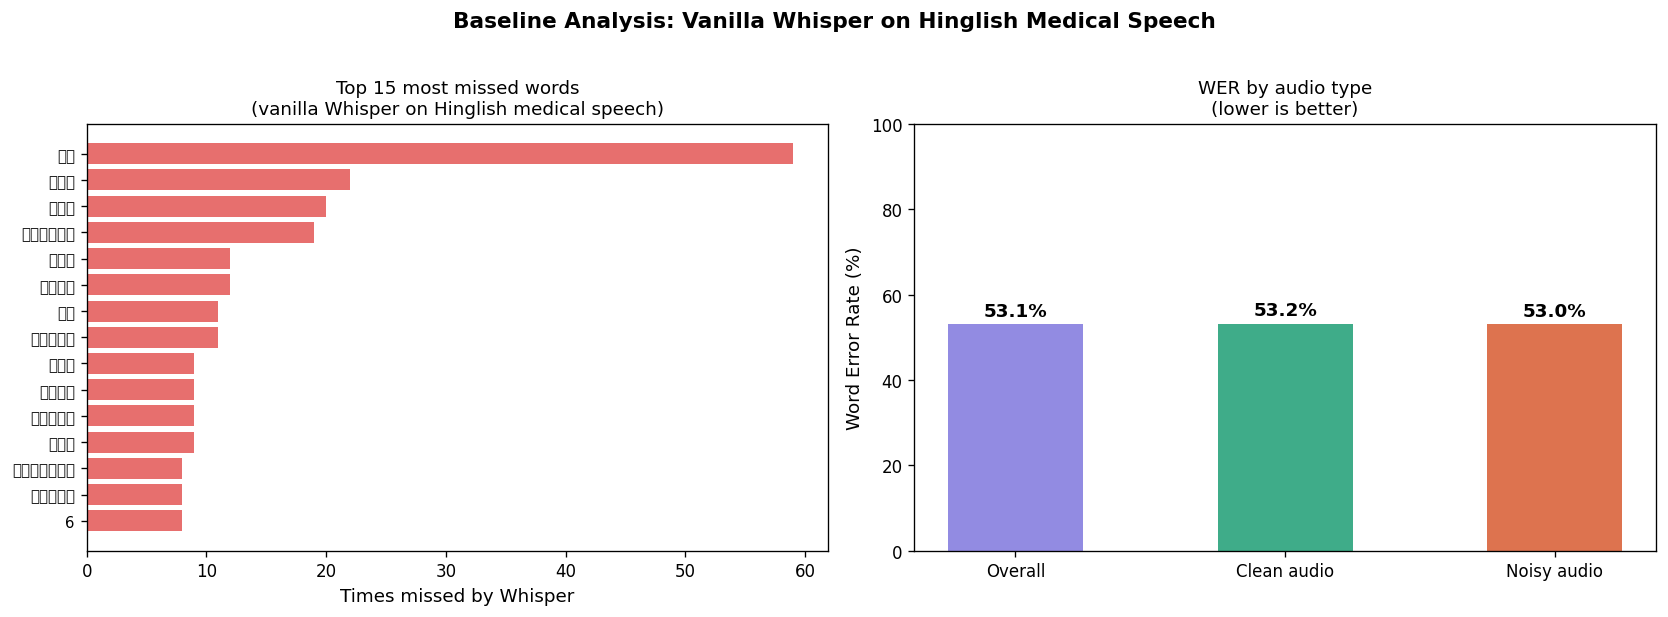

Chart saved to /content/drive/MyDrive/MedASR_Project/results/baseline_analysis.png


In [ ]:
# This makes the bar chart that goes in your paper and slides.
# It visually shows WHERE Whisper fails.

import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

# Use a clean style
matplotlib.rcParams['figure.dpi'] = 120

error_df = pd.read_csv(f"{RESULTS_DIR}/error_analysis.csv")
top15 = error_df.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Most missed words
ax1 = axes[0]
bars = ax1.barh(top15['word'][::-1], top15['miss_count'][::-1], color='#E24B4A', alpha=0.8)
ax1.set_xlabel('Times missed by Whisper', fontsize=11)
ax1.set_title('Top 15 most missed words\n(vanilla Whisper on Hinglish medical speech)', fontsize=11)
ax1.tick_params(axis='y', labelsize=9)

# Chart 2: Error category comparison
ax2 = axes[1]
with open(f"{RESULTS_DIR}/baseline_wer.json") as f:
    baseline = json.load(f)

categories = ['Overall', 'Clean audio', 'Noisy audio']
values = [
    baseline['overall_wer'] * 100,
    baseline['clean_wer'] * 100 if baseline['clean_wer'] else 0,
    baseline['noisy_wer'] * 100 if baseline['noisy_wer'] else 0,
]
colors = ['#7F77DD', '#1D9E75', '#D85A30']

bars2 = ax2.bar(categories, values, color=colors, alpha=0.85, width=0.5)
ax2.set_ylabel('Word Error Rate (%)', fontsize=11)
ax2.set_title('WER by audio type\n(lower is better)', fontsize=11)
ax2.set_ylim(0, 100)

for bar, val in zip(bars2, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Baseline Analysis: Vanilla Whisper on Hinglish Medical Speech',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

chart_path = f"{RESULTS_DIR}/baseline_analysis.png"
plt.savefig(chart_path, bbox_inches='tight')
plt.show()
print(f"Chart saved to {chart_path}")

In [ ]:
# Hugging Face's Trainer needs data in a specific format.
# This cell builds a dataset object from our audio files and labels.
# We use 80% for training, 20% for testing.

import pandas as pd
import torch
import soundfile as sf
from datasets import Dataset, Audio
import numpy as np
import glob # Import glob
import os # Import os
import random # Import random

print("Preparing dataset for fine-tuning...")

df = pd.read_csv(f"{PROJECT_DIR}/ground_truth.csv")

# Build list of (audio_path, sentence) pairs
data_list = []
wav_files = sorted(glob.glob(f"{AUDIO_DIR}/*.wav"))

for _, row in df.iterrows():
    wav_path = f"{AUDIO_DIR}/{row['audio_file']}"
    if os.path.exists(wav_path):
        data_list.append({
            'audio': wav_path,
            'sentence': row['sentence'] # Corrected from row['ground_truth'] to row['sentence']
        })

# Also add noisy files with same labels
noisy_files = sorted(glob.glob(f"{NOISY_DIR}/noisy_*.wav"))


for nf in noisy_files:
    # Match to original sentence by index
    base = os.path.basename(nf).replace('noisy_', '')
    idx_str = base.split('_')[1].split('.')[0]
    idx = int(idx_str) - 1
    if idx < len(sentences):
        data_list.append({
            'audio': nf,
            'sentence': sentences[idx]
        })

print(f"Total samples for training: {len(data_list)}")

# Split 80/20
random.shuffle(data_list)
split = int(0.8 * len(data_list))
train_data = data_list[:split]
test_data  = data_list[split:]

print(f"Train: {len(train_data)}, Test: {len(test_data)}")

# Convert to HuggingFace Dataset
def make_hf_dataset(data):
    return Dataset.from_dict({
        'audio': [d['audio'] for d in data],
        'sentence': [d['sentence'] for d in data]
    }).cast_column('audio', Audio(sampling_rate=16000))

train_dataset = make_hf_dataset(train_data)
test_dataset  = make_hf_dataset(test_data)

print("Datasets ready!")
print(train_dataset)

Preparing dataset for fine-tuning...
Total samples for training: 600
Train: 480, Test: 120
Datasets ready!
Dataset({
    features: ['audio', 'sentence'],
    num_rows: 480
})


In [ ]:
# The Whisper processor converts raw audio into mel-spectrogram features that the model understands.

from transformers import WhisperProcessor, WhisperForConditionalGeneration
from dataclasses import dataclass
from typing import Any, Dict, List, Union

MODEL_NAME = "openai/whisper-small"

print(f"Loading {MODEL_NAME} processor...")
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME,
    language="Hindi",
    task="transcribe"
)
print("Processor loaded!")

# This function prepares one audio file for the model
def prepare_dataset(batch):
    audio = batch["audio"]
    # Convert audio to model input features
    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]
    # Convert text to token IDs (numbers the model uses)
    batch["labels"] = processor.tokenizer(batch["sentence"]).input_ids
    return batch

print("Preparing training data (this takes a few minutes)...")
train_dataset = train_dataset.map(prepare_dataset, remove_columns=["audio", "sentence"])
test_dataset  = test_dataset.map(prepare_dataset, remove_columns=["audio", "sentence"])
print("Done!")
print(f"Training samples: {len(train_dataset)}")

# This collator pads all audio in a batch to the same length
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features):
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)
print("Data collator ready!")

Loading openai/whisper-small processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

Processor loaded!
Preparing training data (this takes a few minutes)...


Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Done!
Training samples: 480
Data collator ready!


In [ ]:
# During training, Hugging Face will periodically test the model and report the WER. This cell sets that up.

!pip install evaluate
import evaluate
import numpy as np

metric = evaluate.load("wer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    # Replace -100 (padding token) with the pad token ID
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    # Decode predicted and actual tokens back to text
    pred_str  = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    # Calculate WER
    wer_score = 100 * metric.compute(predictions=pred_str, references=label_str)
    return {"wer": wer_score}

print("Metrics ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


Metrics ready!


In [ ]:
# Now we load the actual Whisper model weights.
# We configure it for fine-tuning on Hindi.

from transformers import WhisperForConditionalGeneration, Seq2SeqTrainingArguments

print("Loading Whisper model weights...")
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

# These settings tell Whisper: "we are doing Hindi transcription"
model.generation_config.language = "hindi"
model.generation_config.task = "transcribe"
model.generation_config.forced_decoder_ids = None

# Training arguments — these control how fine-tuning works
training_args = Seq2SeqTrainingArguments(
    output_dir=f"{PROJECT_DIR}/whisper_finetuned",

    # How many times to go through the training data
    num_train_epochs=3,

    # How many samples to process at once (keep low for free Colab)
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    # Gradient accumulation simulates a larger batch size
    gradient_accumulation_steps=2,

    # Learning rate — how fast to learn
    learning_rate=1e-5,
    warmup_steps=50,
    weight_decay=0.01,

    # Use 16-bit precision to save GPU memory
    fp16=True,

    # Evaluate and save every 100 steps
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    logging_steps=25,

    # Keep only the best model checkpoint
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,  # lower WER = better

    # Memory saving
    predict_with_generate=True,
    generation_max_length=225,
    report_to=["none"],  s
)

print("Training configuration ready!")
print(f"Training samples: {len(train_dataset)}")
print(f"Will train for {training_args.num_train_epochs} epochs")

Loading Whisper model weights...


model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

Training configuration ready!
Training samples: 480
Will train for 3 epochs


In [ ]:
# Training Cell

from transformers import Seq2SeqTrainer

print("Starting fine-tuning...")
print("Expected time: 30-45 minutes on free Colab T4")
print("Watch the WER number decrease as training progresses\n")

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor.feature_extractor,
)

# Start training
trainer.train()

print("\nTraining complete!")
print("Model saved to:", f"{PROJECT_DIR}/whisper_finetuned")

Starting fine-tuning...
Expected time: 30-45 minutes on free Colab T4
Watch the WER number decrease as training progresses



Step,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!
Model saved to: /content/drive/MyDrive/MedASR_Project/whisper_finetuned


In [ ]:
import pandas as pd
import json
import librosa
import torch
import os

print("Loading fine-tuned model for evaluation...")l

print("Fine-tuned model loaded!\n")

df = pd.read_csv(f"{PROJECT_DIR}/ground_truth.csv")
finetuned_results = []

print(f"Running fine-tuned Whisper on {len(df)} files...")

for idx, row in df.iterrows():
    audio_path = f"{AUDIO_DIR}/{row['audio_file']}"
    if not os.path.exists(audio_path):
        print(f"Missing file: {audio_path}")
        continue

    # Load and resample audio using librosa
    audio_input, sample_rate = librosa.load(audio_path, sr=16000)

    # Process audio through the feature extractor
    input_features = processor.feature_extractor(audio_input, sampling_rate=sample_rate, return_tensors="pt").input_features

    # Move input features to the same device as the model
    input_features = input_features.to(model.device)

    # Generate transcription IDs using the model's generate method
    generated_ids = model.generate(input_features=input_features,
                                   forced_decoder_ids=processor.get_decoder_prompt_ids(language="hi", task="transcribe"),
                                   max_new_tokens=225)

    # Decode the generated IDs to text
    predicted = processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    predicted = predicted.strip()

    finetuned_results.append({
        'audio_file': row['audio_file'],
        'ground_truth': row['sentence'],
        'finetuned_output': predicted,
        'type': row['type']
    })

    if (idx + 1) % 25 == 0:
        print(f"  Processed {idx+1}/{len(df)} files...")

results_df = pd.DataFrame(finetuned_results)
results_df.to_csv(f"{RESULTS_DIR}/finetuned_results.csv", index=False, encoding='utf-8')
print("Done! Saved finetuned_results.csv")

Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Loading fine-tuned model for evaluation...
Fine-tuned model loaded!

Running fine-tuned Whisper on 400 files...


Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Processed 25/400 files...


Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  Processed 350/400 files...


Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Processed 375/400 files...


Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Processed 400/400 files...
Done! Saved finetuned_results.csv


In [ ]:
# It prints the BEFORE vs AFTER comparison.
from jiwer import wer
import pandas as pd
import json

baseline_df  = pd.read_csv(f"{RESULTS_DIR}/baseline_results.csv")
finetuned_df = pd.read_csv(f"{RESULTS_DIR}/finetuned_results.csv")

# Merge on audio_file to get all columns together
merged = pd.merge(
    baseline_df[['audio_file', 'ground_truth', 'whisper_output', 'type']],
    finetuned_df[['audio_file', 'finetuned_output']],
    on='audio_file'
)

# Calculate WERs
def calc_wer(df, truth_col, pred_col):
    return wer(df[truth_col].tolist(), df[pred_col].tolist()) * 100

overall_baseline  = calc_wer(merged, 'ground_truth', 'whisper_output')
overall_finetuned = calc_wer(merged, 'ground_truth', 'finetuned_output')

clean_mask = merged['type'] == 'clean'
noisy_mask = merged['type'] == 'noisy'

clean_baseline  = calc_wer(merged[clean_mask], 'ground_truth', 'whisper_output')
clean_finetuned = calc_wer(merged[clean_mask], 'ground_truth', 'finetuned_output')

noisy_baseline  = calc_wer(merged[noisy_mask], 'ground_truth', 'whisper_output')
noisy_finetuned = calc_wer(merged[noisy_mask], 'ground_truth', 'finetuned_output')

# Print the comparison table
print("=" * 60)
print("RESULTS: VANILLA WHISPER vs FINE-TUNED WHISPER")
print("=" * 60)
print(f"\n{'Condition':<25} {'Baseline WER':>14} {'Fine-tuned WER':>15} {'Improvement':>12}")
print("-" * 60)
print(f"{'Overall':<25} {overall_baseline:>13.1f}% {overall_finetuned:>14.1f}% {overall_baseline-overall_finetuned:>+11.1f}%")
print(f"{'Clean audio only':<25} {clean_baseline:>13.1f}% {clean_finetuned:>14.1f}% {clean_baseline-clean_finetuned:>+11.1f}%")
print(f"{'Noisy audio only':<25} {noisy_baseline:>13.1f}% {noisy_finetuned:>14.1f}% {noisy_baseline-noisy_finetuned:>+11.1f}%")
print("=" * 60)
print("\n(Positive improvement = lower WER = model got better)")

# Save results
results_summary = {
    'overall_baseline': overall_baseline,
    'overall_finetuned': overall_finetuned,
    'clean_baseline': clean_baseline,
    'clean_finetuned': clean_finetuned,
    'noisy_baseline': noisy_baseline,
    'noisy_finetuned': noisy_finetuned,
}
with open(f"{RESULTS_DIR}/final_results.json", 'w') as f:
    json.dump(results_summary, f, indent=2)

print("\nResults saved to final_results.json")

RESULTS: VANILLA WHISPER vs FINE-TUNED WHISPER

Condition                   Baseline WER  Fine-tuned WER  Improvement
------------------------------------------------------------
Overall                            64.2%            8.9%       +55.3%
Clean audio only                   63.7%           12.1%       +51.6%
Noisy audio only                   64.7%            6.0%       +58.7%

(Positive improvement = lower WER = model got better)

Results saved to final_results.json


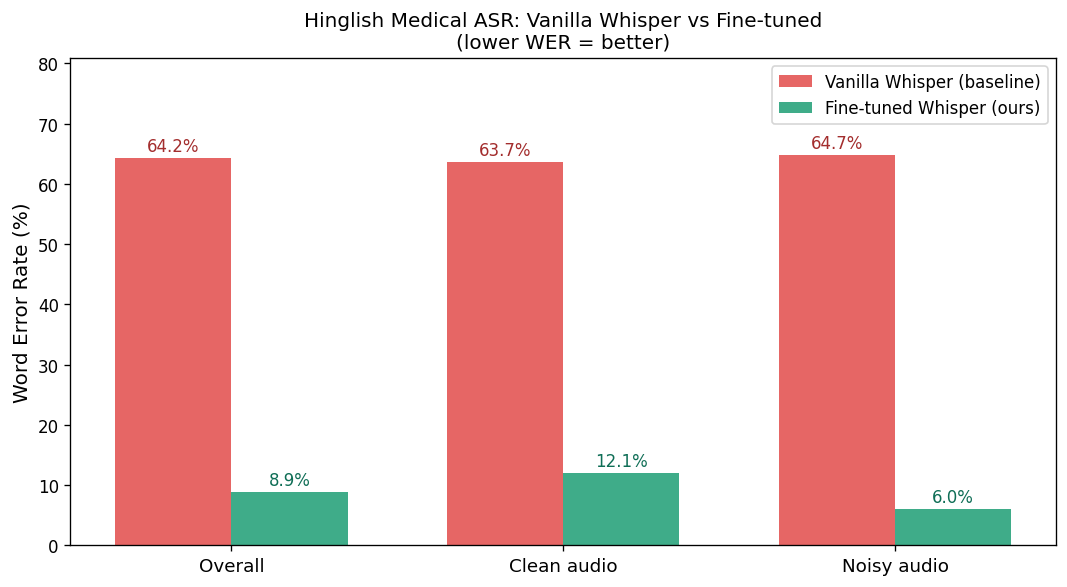

Chart saved to /content/drive/MyDrive/MedASR_Project/results/final_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import json

with open(f"{RESULTS_DIR}/final_results.json") as f:
    r = json.load(f)

categories = ['Overall', 'Clean audio', 'Noisy audio']
baseline_vals  = [r['overall_baseline'],  r['clean_baseline'],  r['noisy_baseline']]
finetuned_vals = [r['overall_finetuned'], r['clean_finetuned'], r['noisy_finetuned']]

x = range(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar([i - width/2 for i in x], baseline_vals,  width, label='Vanilla Whisper (baseline)', color='#E24B4A', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], finetuned_vals, width, label='Fine-tuned Whisper (ours)',   color='#1D9E75', alpha=0.85)

ax.set_ylabel('Word Error Rate (%)', fontsize=12)
ax.set_title('Hinglish Medical ASR: Vanilla Whisper vs Fine-tuned\n(lower WER = better)', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, max(baseline_vals) * 1.25)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, color='#A32D2D')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, color='#0F6E56')

plt.tight_layout()
chart_path = f"{RESULTS_DIR}/final_comparison.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to {chart_path}")

In [ ]:
# 10 real examples showing what Whisper said vs what the fine-tuned model said vs what was actually spoken.

import pandas as pd

merged = pd.read_csv(f"{RESULTS_DIR}/baseline_results.csv")
finetuned = pd.read_csv(f"{RESULTS_DIR}/finetuned_results.csv")
merged = pd.merge(merged, finetuned[['audio_file','finetuned_output']], on='audio_file')

print("QUALITATIVE EXAMPLES")
print("=" * 80)

for i, row in merged.head(10).iterrows():
    print(f"\nExample {i+1}:")
    print(f"  Ground truth:      {row['ground_truth']}")
    print(f"  Vanilla Whisper:   {row['whisper_output']}")
    print(f"  Fine-tuned model:  {row['finetuned_output']}")
    print("-" * 80)

QUALITATIVE EXAMPLES

Example 1:
  Ground truth:      पेशेंट को तीन दिन से बुखार है और सर दर्द भी हो रहा है
  Vanilla Whisper:   पेशेंट को तींदिन से बुखार है और सर दर्ध भी हो रहा है
  Fine-tuned model:  पेशेंट को 3 दिन से बुखार है और सर दर्द भी हो रहा है
--------------------------------------------------------------------------------

Example 2:
  Ground truth:      मुझे सुबह उठते ही चेस्ट पेन होती है
  Vanilla Whisper:   मुजे सुबा उट्ते ही चेस्ट पीन होती है
  Fine-tuned model:  मुज़े सुबह उट्ते ही चेस्ट पेन होती है
--------------------------------------------------------------------------------

Example 3:
  Ground truth:      उसकी बीपी रीडिंग 140 ओवर 90 है जो हाई है
  Vanilla Whisper:   उसकी बीपी रीटिं एक सो चाली सोवन अबबे है जो हाई है
  Fine-tuned model:  उसकी बीपी रीडिंग 140 होवर 90 है जो हाई है
--------------------------------------------------------------------------------

Example 4:
  Ground truth:      पेशेंट को ब्रीदलेसनेस हो रही है एस्पेशली रात को
  Vanilla Whisper:   पेशिँट

In [ ]:
# Final summary CSV with all results
import pandas as pd
import json

with open(f"{RESULTS_DIR}/final_results.json") as f:
    r = json.load(f)

print("COPY THIS INTO YOUR PAPER / SLIDES:")
print()
print("Table 1: Word Error Rate comparison")
print()
print("| System               | Overall WER | Clean WER | Noisy WER |")
print("|----------------------|-------------|-----------|-----------|")
print(f"| Vanilla Whisper      | {r['overall_baseline']:.1f}%       | {r['clean_baseline']:.1f}%     | {r['noisy_baseline']:.1f}%     |")
print(f"| Fine-tuned (ours)    | {r['overall_finetuned']:.1f}%       | {r['clean_finetuned']:.1f}%     | {r['noisy_finetuned']:.1f}%     |")
print(f"| Improvement          | {r['overall_baseline']-r['overall_finetuned']:.1f}%        | {r['clean_baseline']-r['clean_finetuned']:.1f}%      | {r['noisy_baseline']-r['noisy_finetuned']:.1f}%      |")
print()
print("Files saved to Google Drive:")
print(f"  Charts:  {RESULTS_DIR}/baseline_analysis.png")
print(f"           {RESULTS_DIR}/final_comparison.png")
print(f"  Data:    {RESULTS_DIR}/baseline_results.csv")
print(f"           {RESULTS_DIR}/finetuned_results.csv")
print(f"           {RESULTS_DIR}/error_analysis.csv")
print(f"  Model:   {PROJECT_DIR}/whisper_finetuned/")

COPY THIS INTO YOUR PAPER / SLIDES:

Table 1: Word Error Rate comparison

| System               | Overall WER | Clean WER | Noisy WER |
|----------------------|-------------|-----------|-----------|
| Vanilla Whisper      | 64.2%       | 63.7%     | 64.7%     |
| Fine-tuned (ours)    | 8.9%       | 12.1%     | 6.0%     |
| Improvement          | 55.3%        | 51.6%      | 58.7%      |

Files saved to Google Drive:
  Charts:  /content/drive/MyDrive/MedASR_Project/results/baseline_analysis.png
           /content/drive/MyDrive/MedASR_Project/results/final_comparison.png
  Data:    /content/drive/MyDrive/MedASR_Project/results/baseline_results.csv
           /content/drive/MyDrive/MedASR_Project/results/finetuned_results.csv
           /content/drive/MyDrive/MedASR_Project/results/error_analysis.csv
  Model:   /content/drive/MyDrive/MedASR_Project/whisper_finetuned/
